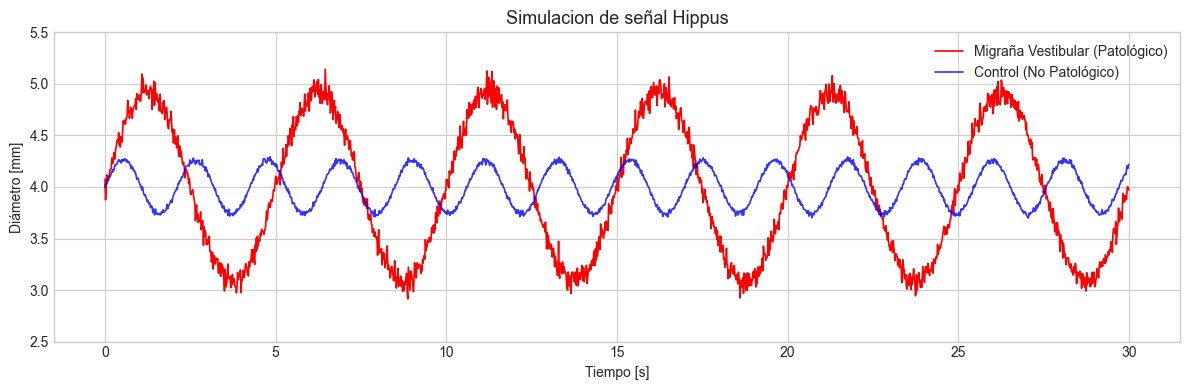

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración global
fs = 60.0
duracion = 30.0
t = np.linspace(0, duracion, int(fs * duracion))

def simular_pupila(es_mv=False):
    base = 4.0
    
    if es_mv:
        # Criterios MV: Amplitud exagerada y frecuencia marcada
        amp_media = np.random.uniform(0.6, 1.0) 
        freq = 0.2
        std_ruido = 0.05
    else:
        # Criterios Control: Estabilidad
        amp_media = np.random.uniform(0.1, 0.3)
        freq = np.random.uniform(0.2, 0.5)
        std_ruido = 0.01

    # Jitter: Variabilidad biológica en la amplitud (5%)
    jitter_amp = amp_media + np.random.normal(0, amp_media * 0.05, len(t))
    
    # Modelo: Senoidal (Hippus) + Ruido (Falla de inhibición central)
    onda = jitter_amp * np.sin(2 * np.pi * freq * t)
    ruido = np.random.normal(0, std_ruido, len(t))
    
    return base + onda + ruido

#  Grafico
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t, simular_pupila(es_mv=True),  label="Migraña Vestibular (Patológico)", color='red', lw=1.2)
ax.plot(t, simular_pupila(es_mv=False), label="Control (No Patológico)", color='blue', lw=1.2, alpha=0.8)

ax.set_title('Simulacion de señal Hippus', fontsize=13)
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Diámetro [mm]')
ax.set_ylim([2.5, 5.5])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()